In [2]:
import sys
import getpass

user = getpass.getuser()
sys.dont_write_bytecode = True

# for DataViz team members
sys.path.insert(0, '/Users/{}/Box/Utility Code'.format(user))

from utils_io import *
import matplotlib.pyplot as plt

## Read CES 3.0 and 4.0 tables

In [4]:
ls 'data'

CES4 BayAreaSummary.xlsx
CalEnviroScreen_4_Top_25_Percentile_Statistics.xls
CoC_Tracts_and_Population_by_County.xls
calenviroscreen40resultsdatadictionaryf2021/
calenviroscreen4_final_2021.xlsx
ces3results.xlsx


In [7]:
ces_4 = pd.read_excel('data/calenviroscreen4_final_2021.xlsx',sheet_name=0,engine='openpyxl')

In [9]:
ces_3 = pd.read_excel('data/ces3results.xlsx',sheet_name='CES 3.0 (2018 Update)',engine='openpyxl')

In [10]:
ces_3['California County'].unique()

array(['Fresno ', 'San Bernardino', 'San Joaquin', 'Los Angeles',
       'Stanislaus ', 'Kern ', 'Riverside ', 'San Diego', 'Sacramento ',
       'Merced ', 'Kings ', 'Alameda ', 'Ventura ', 'Imperial ',
       'Orange ', 'Tulare ', 'Madera ', 'Contra Costa', 'Yolo ',
       'Santa Clara', 'San Francisco', 'Solano ', 'San Mateo', 'Yuba ',
       'Butte ', 'Santa Cruz', 'Monterey ', 'Sutter ', 'Sonoma ',
       'Santa Barbara', 'Napa ', 'San Benito', 'Tehama ', 'Nevada ',
       'Marin ', 'Glenn ', 'Mendocino ', 'Placer ', 'Siskiyou ',
       'Colusa ', 'Shasta ', 'Tuolumne ', 'Inyo ', 'Amador ', 'Humboldt ',
       'San Luis Obispo', 'Lake ', 'Calaveras ', 'Modoc ', 'Lassen ',
       'Plumas ', 'Sierra ', 'Mariposa ', 'El Dorado', 'Del Norte',
       'Mono ', 'Trinity ', 'Alpine '], dtype=object)

In [11]:
ces_4['California County'].unique()

array(['Fresno ', 'San Joaquin', 'Los Angeles', 'Stanislaus ',
       'San Bernardino', 'Kern ', 'Riverside ', 'Madera ', 'Kings ',
       'Sacramento ', 'Merced ', 'San Diego', 'Solano ', 'Alameda ',
       'Orange ', 'Tulare ', 'Contra Costa', 'Imperial ', 'Yolo ',
       'Sutter ', 'Santa Clara', 'San Francisco', 'Ventura ', 'Yuba ',
       'San Mateo', 'Monterey ', 'Butte ', 'Santa Cruz', 'Santa Barbara',
       'Glenn ', 'Sonoma ', 'Humboldt ', 'Lake ', 'Mendocino ', 'Marin ',
       'Tehama ', 'Nevada ', 'Napa ', 'San Benito', 'Placer ', 'Colusa ',
       'Shasta ', 'Modoc ', 'Lassen ', 'Siskiyou ', 'Del Norte',
       'Tuolumne ', 'Mariposa ', 'Amador ', 'San Luis Obispo',
       'Calaveras ', 'El Dorado', 'Inyo ', 'Plumas ', 'Trinity ',
       'Sierra ', 'Mono ', 'Alpine '], dtype=object)

## Create quartile bins

In [14]:
ces_4.rename(columns={'Census Tract':'geoid',
                      ' CES 4.0 Percentile':'ces_4_percentile',
                      'California County':'county'},inplace=True)

In [16]:
ces_3.rename(columns={'Census Tract':'geoid',
                      ' CES 3.0 Percentile':'ces_3_percentile',
                     'California County':'county'},inplace=True)

In [17]:
ces_4['ces_score_quart'] = pd.cut(ces_4.ces_4_percentile,bins=range(0,101,25))

In [18]:
ces_3['ces_score_quart'] = pd.cut(ces_3.ces_3_percentile,bins=range(0,101,25))

## Select out Bay Area Counties

In [19]:
bay_area = ['Marin',
            'Sonoma',
            'Napa',
            'Solano',
            'Contra Costa',
            'Alameda',
            'Santa Clara',
            'San Mateo',
           'San Francisco']

In [20]:
#strip whitespace from county names
ces_3['county'] = ces_3['county'].str.strip()

In [21]:
#strip whitespace from county names
ces_4['county'] = ces_4['county'].str.strip()

In [22]:
ces_3_bay_area = ces_3.loc[ces_3['county'].isin(bay_area)]

In [23]:
ces_4_bay_area = ces_4.loc[ces_4['county'].isin(bay_area)]

In [24]:
#set index as geoid
ces_3_bay_area = ces_3_bay_area.set_index('geoid')

In [25]:
#set index as geoid
ces_4_bay_area = ces_4_bay_area.set_index('geoid')

## Concatenate CES 3 and CES 4

In [26]:
VAR = 'ces_score_quart'
comparison_bayarea = pd.concat([ces_3_bay_area[[VAR]],
           ces_4_bay_area[[VAR]]],
           axis=0,names=['vintage','geoid'],
           keys=['v3','v4']).reset_index()

In [27]:
comparison_bayarea.head(10)

,vintage,geoid,ces_score_quart
0,v3,6001409000,"(75, 100]"
1,v3,6001409100,"(75, 100]"
2,v3,6001408800,"(75, 100]"
3,v3,6013379000,"(75, 100]"
4,v3,6013312000,"(75, 100]"
5,v3,6001409200,"(75, 100]"
6,v3,6013365002,"(75, 100]"
7,v3,6085503105,"(75, 100]"
8,v3,6013377000,"(75, 100]"
9,v3,6001407300,"(75, 100]"


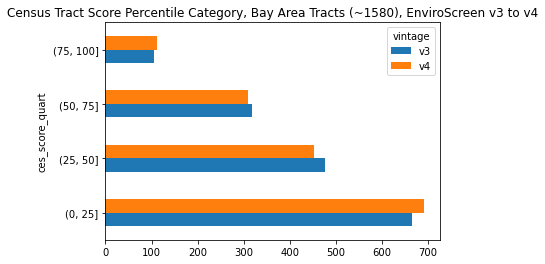

In [28]:
ax=comparison_bayarea.groupby(['vintage',VAR]).size().unstack(0).plot(kind='barh',fig=[6,9.5])
plt.title('Census Tract Score Percentile Category, Bay Area Tracts (~1580), EnviroScreen v3 to v4',size=12);
#ax.annotate('\nNote that the Bay Area as a whole\nmay just perform better than the state',xy=(0.5,.5),xycoords='axes fraction')
#plt.savefig('/Users/aolsen/Downloads/enviroscreen_deciles.png',dpi=300)

In [29]:
comparison_bayarea.to_csv('data/ces3_4_comparision_quartiles_bay_area.csv')

## Summarize population and tract count by county

In [30]:
ces_4_bay_area.columns

Index(['Total Population', 'county', 'ZIP', 'Approximate Location',
       'Longitude', 'Latitude', 'CES 4.0 Score', 'ces_4_percentile',
       'CES 4.0 Percentile Range', 'Ozone', 'Ozone Pctl', 'PM2.5',
       'PM2.5 Pctl', 'Diesel PM', 'Diesel PM Pctl', 'Drinking Water',
       'Drinking Water Pctl', 'Lead', 'Lead Pctl', 'Pesticides',
       'Pesticides Pctl', 'Tox. Release', 'Tox. Release Pctl', 'Traffic',
       'Traffic Pctl', 'Cleanup Sites', 'Cleanup Sites Pctl',
       'Groundwater Threats', 'Groundwater Threats Pctl', 'Haz. Waste',
       'Haz. Waste Pctl', 'Imp. Water Bodies', 'Imp. Water Bodies Pctl',
       'Solid Waste', 'Solid Waste Pctl', 'Pollution Burden',
       'Pollution Burden Score', 'Pollution Burden Pctl', 'Asthma',
       'Asthma Pctl', 'Low Birth Weight', 'Low Birth Weight Pctl',
       'Cardiovascular Disease', 'Cardiovascular Disease Pctl', 'Education',
       'Education Pctl', 'Linguistic Isolation', 'Linguistic Isolation Pctl',
       'Poverty', 'Poverty P

In [38]:
#Add flag for disadvantaged community

ces_4_bay_area['disadvantaged'] = np.where(ces_4_bay_area['ces_4_percentile'] >= 75,1,0)

In [39]:
ces_4_bay_area[ces_4_bay_area['disadvantaged'] == 1]

,Total Population,county,ZIP,Approximate Location,Longitude,Latitude,CES 4.0 Score,ces_4_percentile,CES 4.0 Percentile Range,Ozone,...,Poverty Pctl,Unemployment,Unemployment Pctl,Housing Burden,Housing Burden Pctl,Pop. Char.,Pop. Char. Score,Pop. Char. Pctl,ces_score_quart,disadvantaged
geoid,,,,,,,,,,,,,,,,,,,,,
6095250701,3529,Solano,94590,Vallejo,-122.244902,38.090042,65.121123,97.869390,95-100% (highest scores),0.036244,...,61.080402,12.7,93.714211,25.2,80.747782,84.702998,8.786454,96.419566,"(75, 100]",1
6001407300,2420,Alameda,94601,Oakland,-122.210924,37.762179,65.033685,97.844175,95-100% (highest scores),0.029372,...,81.909548,11.0,89.666840,35.5,96.527250,82.401839,8.547749,94.856278,"(75, 100]",1
6001409000,4687,Alameda,94621,Oakland,-122.221368,37.720011,63.172581,97.175996,95-100% (highest scores),0.030640,...,75.716080,7.3,69.976575,23.0,74.043093,81.647104,8.469458,94.162885,"(75, 100]",1
6001408800,7149,Alameda,94621,Oakland,-122.196942,37.758804,61.006902,96.243066,95-100% (highest scores),0.030640,...,95.000000,8.7,79.724102,23.3,75.107731,86.773704,9.001254,97.743318,"(75, 100]",1
6013365002,5590,Contra Costa,94801,North Richmond,-122.384395,37.959466,60.675239,96.142209,95-100% (highest scores),0.031908,...,75.716080,4.8,41.840187,25.5,81.520913,81.979672,8.503957,94.465456,"(75, 100]",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6013308001,7653,Contra Costa,94509,Antioch,-121.796422,37.991924,40.256063,75.390822,75-80%,0.043811,...,62.663317,12.9,94.091619,24.0,77.211660,77.747572,8.064950,89.939486,"(75, 100]",1
6013314103,5629,Contra Costa,94565,Bay Point,-121.943526,38.039171,40.171703,75.264750,75-80%,0.042599,...,75.716080,10.6,88.404477,24.6,79.062104,72.555938,7.526409,83.408976,"(75, 100]",1
6013373000,4468,Contra Costa,94801,Richmond,-122.353813,37.947619,40.148162,75.201715,75-80%,0.030640,...,79.195980,5.2,46.993753,17.1,49.721166,65.477004,6.792094,73.726677,"(75, 100]",1


In [43]:
(ces_4_bay_area[['Total Population','county','disadvantaged']][ces_4_bay_area['disadvantaged'] == 1]
 .groupby('county').agg({'disadvantaged':'sum','Total Population':'sum'})).reset_index()

,county,disadvantaged,Total Population
0,Alameda,35,141263
1,Contra Costa,32,192942
2,San Francisco,14,55114
3,San Mateo,7,40409
4,Santa Clara,11,50722
5,Solano,13,55934
6,Sonoma,1,3949
